# Intégration d'EDO sur Python

## 1- Solution numérique

### 1-a. Installation des bibliothèques et importation des modules d'intégration

In [10]:
conda install matplotlib numpy

Retrieving notices: done
Channels:
 - conda-forge
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [11]:
# numpy: calcul, matplotlib: graphiques, scipy: intégration

# module scipy.integrate pour l'intégration
# ivp : Inital value problem (problème à condition initiale)

import scipy as scp

#attention: bien le nommer scp et non sp (voir plus loin, une autre bibliothèque s'appelle aussi sp (abréviation de sympy))

from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

### 1-b. Définition de l'équation différentielle

On s'intéresse à l'EDO suivante : $ \dfrac{dL}{dt} = 3L $, avec une condition initiale $ L(0)=1 $

Le code représentant cette EDO est le suivant : 

In [12]:
def equation(t, L):

# equation représente la dérivée dL/dt.

#Paramètres
    
    #t : float
    #    Temps courant.
    #   Fourni automatiquement par solve_ivp.

    #L : float ou ndarray
    #    Valeur courante de la variable L à un instant t

# Retour
    
    #float ou ndarray
    # Valeur de la dérivée dL/dt à modifier en fonction de l'EDO

    return 3 * L


### 1-c. Définition des conditions initiales


In [13]:
y0 = [1]

# La fonction qui va résoudre l'EDO (solve_ivp) 
# attend une liste pour la valeur de L en condition initiale

### 1-d. Intervalle d'intégration et nombre de points d'évaluation

In [14]:
t0 = 0
tf = 2
t_eval=np.linspace(t0, tf, 200)

#np.linspace(a,b,n) crée n points régulièrement espacés entre a et b

### 1-e. Résolution numérique

#### Principe : la méthode d'Euler



Pour calculer la valeur au pas de temps suivant, on écrit $L(t+dt) = L(t) + \dfrac{dL}{dt} dt$

On a $L(0+dt) = L(0) + \dfrac{dL}{dt} dt$
             =$ L(0) + 3*L(0) * dt$

On peut par exemple calculer pour dt = 0.5

La  fonction solve_ivp fonctionne selon cette méthode, en cherchant le dt le plus adapté à chaque nouveau pas de temps pour réprésenter au mieux la fonction intégrée

In [15]:
solution = solve_ivp(
    fun=equation,
    t_span=(t0, tf),
    y0=y0,
    t_eval=t_eval)

# Paramètres utilisés :

    #fun :  fonction définissant l'équation différentielle,
    # t_span : intervalle de temps étudié
    #y0 :condition initiale.
    #t_eval :instants où l'on souhaite récupérer la solution

#Fonctionnement

    #solve_ip fournit les arguments à equation (t et y) 
    #selon des dt qu'il calcule pour être le plus représentatif possible de la solution
    #sorte de boucle qui calcule toutes les valeurs prises par equation (soit dL/dt)
    #en fonction des valeurs de t et de y
    #en partant des conditions initiales

# Résultat :

    #solution.t: contient les temps.
    #solution.y: contient les valeurs calculées.

### 1-e. Extraction des résultats

In [16]:
t_num = solution.t

L_num = solution.y[0]

# solution.y est un tableau numpy 2D 
# Pour une seule équation : solution.y[0] contient les valeurs de dL/dt calculées
#rangées en une seule colonne correspondant à la variable dL/dt
#solution.t est aussi un tableau (1D)

### 1- f. Affichage résultats

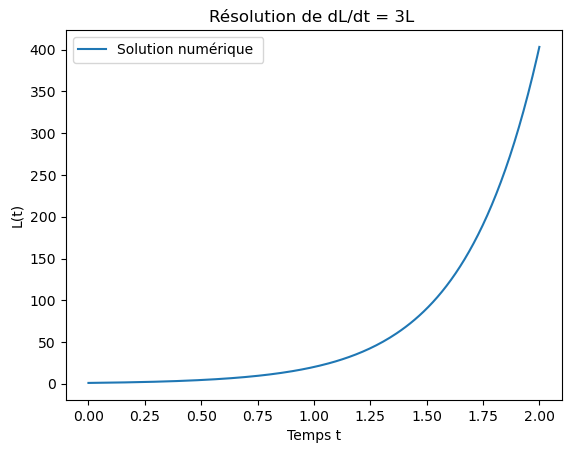

In [17]:
# trace la solution numérique
# t_num :  axe des x
#L_num: axe des y 
#label: légende associée au grahpique 

plt.plot(
    t_num,
    L_num,
    label="Solution numérique ")

# chercher la solution analytique (à coder) puis la superposer graphiquement 

plt.xlabel("Temps t")

# nom de l'axe horizontal

plt.ylabel("L(t)")

# nom de l'axe vertical


plt.title("Résolution de dL/dt = 3L ")

# titre du graphique

plt.legend()

# affiche les légendes

plt.show()

# affiche la figure à l'écran

## 2- Solution analytique

### 2-a.  Installation des bibliothèques et importation des modules d'intégration

Installation:

In [18]:
conda install sympy matplotlib numpy

Channels:
 - conda-forge
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


Importation: 

In [19]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

### 2.b- Définition de la variable indépendante

In [20]:
t = sp.Symbol('t')
# Symbol représente une variable mathématique symbolique.
# Ici t joue le rôle du temps.

### 2.c- Définition de la fonction inconnue

In [21]:
L = sp.Function('L')
# Function crée une fonction symbolique.
# L(t) représente l'inconnue de l'équation.

### 2.d- Définition de l'EDO

In [22]:
equation = sp.Eq(
    sp.Derivative(L(t), t),
    3 * L(t))

# Eq construit une égalité mathématique sp.Eq(membre gauche, membre droit)
#
# Derivative(L(t), t) représente dL/dt.
#
# Et ici :
# dL/dt = 3L 
# Valeur de la dérivée dL/dt à modifier en fonction de l'EDO


### 2.e- Résolution analytique d'une EDO avec condition initiale

In [23]:
solution_ci = sp.dsolve(
    equation,
    ics={L(0): 1})

print("Solution avec condition initiale :")
sp.pprint(solution_ci)

# dsolve :
# Fonction principale de SymPy pour résoudre les EDO.
#
# Elle prend une équation différentielle en argument (equation)
# et une condition initiale: ics (dictionnaire)
# et retourne la solution analytique.

#forme de solution_ci: Eq(L(t), expression littérale)
#
#sp.pprint : comme print, affiche le résultat


Solution avec condition initiale :
        3⋅t
L(t) = ℯ   


### 2.f- Transformation de la solution pour le tracé

In [24]:
# Extraction du membre de droite
expression = solution_ci.rhs

#.rhs : membre de droite de l'équation, extrait depuis l'objet solution_ci
#en opposition avec .lhs, membre de gauche de l'équation

#conversion en fonction numérique

fonction_numerique = sp.lambdify(
    t,
    expression,
    modules=["numpy"])

#sp.lamdify : transforme une expression symbolique SymPy en fonction 


### 2- g. Affichage résultats

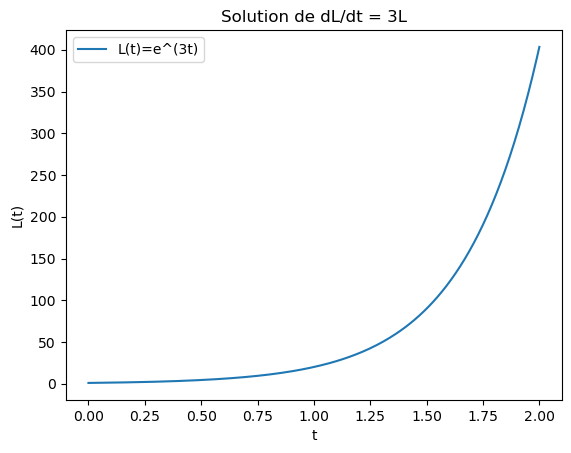

In [25]:
#création de 200 points entre t0 et tf par np.linspace

t_values = np.linspace(0, 2, 200)

# calcul de L(t) pour toutes les valeurs de t stockées dans t_values
# par la fonction créée en 2.f- (fonction_numerique)

L_values = fonction_numerique(t_values)

#tracé du graphique issu de la solution analytique

plt.plot(
    t_values,
    L_values,
    label="L(t)=e^(3t)")

# t_values :  axe des x
#L_values: axe des y 
#label: légende associée au graphique

plt.xlabel("t")

# nom de l'axe horizontal

plt.ylabel("L(t)")

# nom de l'axe vertical

plt.title("Solution de dL/dt = 3L")

# titre du graphique

plt.legend()

# affiche les légendes

plt.show()

# affiche la figure à l'écran

## 3. Erreur entre les deux solutions

On peut chercher à voir la différence de précision entre la solution analytique et la solution numérique, et tracer cette erreur.

In [26]:
#à l'aide de la solution analytique symbolique transformée en fonction numérique (point 2.f-)
# on va calculer la valeur théorique L_ana 
# à chaque pas de temps d'intégration (liste t_num) choisi par solve_ivp
#puis le comparer aux valeurs estimées L_num par solve_ivp

L_ana = fonction_numerique (t_num) 

erreur = L_num - L_ana

In [28]:
print(L_ana)

[  1.           1.03060989   1.06215675   1.09466925   1.12817695
   1.16271033   1.19830076   1.23498062   1.27278324   1.311743
   1.35189531   1.39327667   1.43592472   1.47987822   1.52517713
   1.57186263   1.61997718   1.6695645    1.72066969   1.7733392
   1.82762092   1.88356419   1.94121989   2.00064041   2.0618798
   2.12499371   2.19003954   2.25707641   2.32616527   2.39736894
   2.47075214   2.54638159   2.62432605   2.70465638   2.78744562
   2.87276903   2.96070417   3.051331     3.14473191   3.24099181
   3.34019821   3.44244132   3.54781407   3.65641227   3.76833465
   3.88368296   4.00256207   4.12508006   4.25134831   4.38148161
   4.51559828   4.65382025   4.79627318   4.94308658   5.09439392
   5.25033276   5.41104487   5.57667636   5.74737781   5.92330442
   6.10461612   6.29147775   6.4840592    6.68253554   6.88708722
   7.09790021   7.31516616   7.53908259   7.76985309   8.00768744
   8.25280187   8.50541924   8.76576919   9.03408842   9.31062088
   9.59561797 

Ensuite, on peut visualiser cette erreur. 

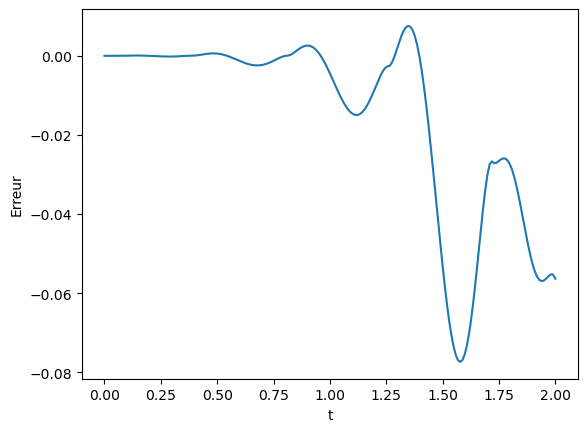

In [29]:
plt.plot(t_num, erreur)
plt.xlabel("t")
plt.ylabel("Erreur")
plt.show()